**Names:** Shadmun Talukder Shahed (ID 1620656), Jonathan Abhishek Rao Thota (ID 2461129)  
**Class:** COSC6380 (Capstone Course)  
**Professor:** Dr. Hardik Gohel, Ph.D.


## Project Overview
This notebook implements a quantum machine learning pipeline for malware classification using the ClaMP dataset. The workflow includes data loading, preprocessing, feature selection, train/test splitting, classical baseline evaluation, and quantum model training using Quantum Support Vector Classifier (QSVC) and Variational Quantum Classifier (VQC).

## Objectives
- Load and preprocess the malware dataset
- Select the most relevant features for classification
- Train and evaluate a classical baseline model
- Train and evaluate quantum models using QSVC and VQC
- Compare model performance and discuss findings

In [68]:
# Install required packages
!pip uninstall -y qiskit qiskit-machine-learning qiskit-algorithms qiskit-ibm-runtime -q
!pip install --no-cache-dir -q \
    "qiskit==2.3.0" \
    "qiskit-machine-learning==0.7.2" \
    "qiskit-algorithms==0.3.0" \
    "qiskit-ibm-runtime==0.22.0" \
    pandas matplotlib seaborn scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 61.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.8/97.8 kB 366.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.6/308.6 kB 396.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 111.4 MB/s eta 0:00:00


## 1. Import Libraries
This section imports all required libraries for data preprocessing, visualization, classical machine learning, and quantum machine learning.

In [69]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from qiskit.primitives import Sampler
from qiskit.circuit.library import ZZFeatureMap, RealAmplitudes
from qiskit_machine_learning.kernels import FidelityQuantumKernel
from qiskit_machine_learning.algorithms import QSVC
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_algorithms.optimizers import COBYLA

np.random.seed(42)

## 2. Data Loading
The ClaMP malware dataset is loaded from the Colab environment. The first few rows are displayed to confirm the dataset was loaded correctly.

In [70]:
dataset_path = "/content/ClaMP_Raw-5184.csv"

if os.path.exists(dataset_path):
    df = pd.read_csv(dataset_path)
    print("CSV loaded successfully!")
    display(df.head())
else:
    raise FileNotFoundError(f"File not found: {dataset_path}")

CSV loaded successfully!


,e_magic,e_cblp,e_cp,e_crlc,e_cparhdr,e_minalloc,e_maxalloc,e_ss,e_sp,e_csum,...,CheckSum,Subsystem,DllCharacteristics,SizeOfStackReserve,SizeOfStackCommit,SizeOfHeapReserve,SizeOfHeapCommit,LoaderFlags,NumberOfRvaAndSizes,class
0,23117,144,3,0,4,0,65535,0,184,0,...,1194954,3,64,1048576,4096,1048576,4096,0,16,0
1,23117,144,3,0,4,0,65535,0,184,0,...,0,2,0,1048576,4096,1048576,4096,0,16,0
2,23117,144,3,0,4,0,65535,0,184,0,...,67688,2,320,1048576,4096,1048576,4096,0,16,0
3,23117,144,3,0,4,0,65535,0,184,0,...,113668,2,1344,1048576,4096,1048576,4096,0,16,0
4,23117,144,3,0,4,0,65535,0,184,0,...,69089,2,33088,262144,8192,1048576,4096,0,16,0


## 3. Data Preprocessing
This section performs data cleaning by:
- removing unnecessary columns
- removing fully null columns
- checking dataset dimensions
- examining class distribution

In [71]:
target = "class"

# Drop irrelevant columns if present
df = df.drop(columns=["e_magic", "e_crlc"], errors="ignore")

# Drop fully null columns
df = df.dropna(axis=1)

print("Dataset shape after cleaning:", df.shape)
print("\nMissing values per column:")
print(df.isna().sum())
print("\nClass distribution:")
print(df[target].value_counts())

Dataset shape after cleaning: (5184, 52)

Missing values per column:
e_cblp                         0
e_cp                           0
e_cparhdr                      0
e_minalloc                     0
e_maxalloc                     0
e_ss                           0
e_sp                           0
e_csum                         0
e_ip                           0
e_cs                           0
e_lfarlc                       0
e_ovno                         0
e_oemid                        0
e_oeminfo                      0
e_lfanew                       0
Machine                        0
NumberOfSections               0
CreationYear                   0
PointerToSymbolTable           0
NumberOfSymbols                0
SizeOfOptionalHeader           0
Characteristics                0
Magic                          0
MajorLinkerVersion             0
MinorLinkerVersion             0
SizeOfCode                     0
SizeOfInitializedData          0
SizeOfUninitializedData        0
Address

- No missing values were found in any column.

**Class distribution:**
  - Class 1 (Malware): **2683 samples**
  - Class 0 (Benign): **2501 samples**




## 4. Exploratory Data Analysis
A correlation analysis is performed to identify features that are most strongly related to the target variable.

The top features selected based on absolute correlation help guide feature selection for both classical and quantum models.

This ensures that the most informative features are used while keeping the dimensionality low for quantum circuits.

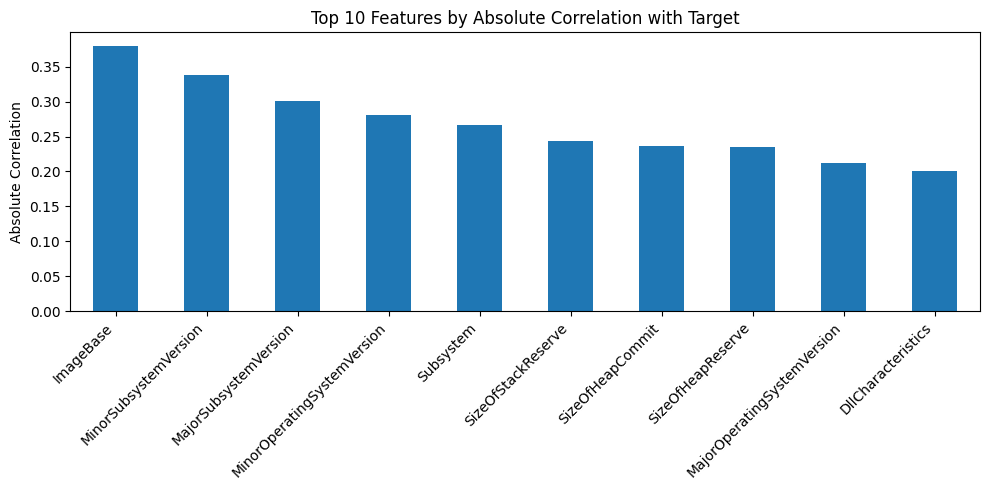

Top correlated features with target:
ImageBase                      0.380096
MinorSubsystemVersion          0.337625
MajorSubsystemVersion          0.300440
MinorOperatingSystemVersion    0.280532
Subsystem                      0.266214
SizeOfStackReserve             0.243861
SizeOfHeapCommit               0.235746
SizeOfHeapReserve              0.235153
MajorOperatingSystemVersion    0.211731
DllCharacteristics             0.199960
Name: class, dtype: float64


In [72]:
correlation_matrix = df.corr(numeric_only=True)
class_correlations = correlation_matrix[target].drop(target)

top_corr = class_correlations.abs().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 5))
top_corr.plot(kind="bar")
plt.title("Top 10 Features by Absolute Correlation with Target")
plt.ylabel("Absolute Correlation")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

print("Top correlated features with target:")
print(top_corr)

## 5. Initial Classical Baseline (Unsuccessful Feature Selection)
An initial classical baseline was tested using an earlier feature-selection approach. This baseline performed poorly and serves as a reference point before applying quantum-oriented feature selection.

In [73]:
# Initial baseline using four manually selected / earlier-selected features
initial_features = ["SizeOfOptionalHeader", "Machine", "e_csum", "e_oeminfo"]
initial_features = [f for f in initial_features if f in df.columns]

X_initial = df[initial_features]
y_initial = df[target]

X_train_init, X_test_init, y_train_init, y_test_init = train_test_split(
    X_initial, y_initial, test_size=0.2, random_state=42, stratify=y_initial
)

initial_model = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", random_state=42)
)

initial_model.fit(X_train_init, y_train_init)
y_pred_init = initial_model.predict(X_test_init)

print("Initial Classical SVM Accuracy:", accuracy_score(y_test_init, y_pred_init))
print("\nInitial Classical SVM Classification Report:\n",
      classification_report(y_test_init, y_pred_init, zero_division=0))
print("\nInitial Classical SVM Confusion Matrix:\n",
      confusion_matrix(y_test_init, y_pred_init))

Initial Classical SVM Accuracy: 0.5197685631629702

Initial Classical SVM Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.00      0.01       500
           1       0.52      1.00      0.68       537

    accuracy                           0.52      1037
   macro avg       0.76      0.50      0.35      1037
weighted avg       0.75      0.52      0.36      1037


Initial Classical SVM Confusion Matrix:
 [[  2 498]
 [  0 537]]


### Results
- Accuracy: **51.98%**
- The model predicted almost all samples as one class.
- Confusion matrix shows:
  - Almost all Class 0 samples were misclassified.
  - Perfect recall for Class 1 but complete failure for Class 0.

### Interpretation
This demonstrates that poor feature selection can severely degrade model performance. The model failed to generalize and exhibited strong bias toward one class.

This motivated a more robust feature selection approach using correlation analysis.

### Baseline Observation
The initial classical baseline performed poorly (≈52% accuracy), indicating that the earlier feature-selection strategy was ineffective.

The model showed extreme class imbalance in predictions, highlighting the importance of selecting meaningful features.

This justified the transition to correlation-based feature selection for both classical and quantum models.

## 6. Quantum-Ready Data Preparation

Because quantum models become expensive as the number of qubits increases, a balanced subset of the dataset is used.

### Dataset Setup
- Total samples used: **200**
- Class distribution:
  - Class 0: **100**
  - Class 1: **100**

### Selected Features (Top 4)
- Subsystem
- MajorLinkerVersion
- ImageBase
- SectionAlignment

### Train/Test Split
- Training samples: **160**
- Testing samples: **40**

This reduction ensures feasibility for quantum models while preserving meaningful structure in the data.

In [74]:
def create_balanced_sample(df, target_column="class", num_samples=200, random_state=42):
    if num_samples % 2 != 0:
        raise ValueError("num_samples must be even.")

    class_0 = df[df[target_column] == 0]
    class_1 = df[df[target_column] == 1]

    half = num_samples // 2

    class_0_sample = class_0.sample(n=half, random_state=random_state)
    class_1_sample = class_1.sample(n=half, random_state=random_state)

    df_balanced = pd.concat([class_0_sample, class_1_sample]) \
        .sample(frac=1, random_state=random_state) \
        .reset_index(drop=True)

    return df_balanced

df_q = create_balanced_sample(df, num_samples=200)

corr_q = df_q.corr(numeric_only=True)[target].drop(target)
top_features = corr_q.abs().sort_values(ascending=False).head(4).index.tolist()

print("Top 4 features for quantum models:", top_features)

X = df_q[top_features]
y = df_q[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Classical scaling
std_scaler = StandardScaler()
X_train_std = std_scaler.fit_transform(X_train)
X_test_std = std_scaler.transform(X_test)

# Quantum scaling
scaler = MinMaxScaler(feature_range=(-1, 1))
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("\ny_train distribution:")
print(y_train.value_counts())

Top 4 features for quantum models: ['Subsystem', 'MajorLinkerVersion', 'ImageBase', 'SectionAlignment']
X_train shape: (160, 4)
X_test shape: (40, 4)

y_train distribution:
class
0    80
1    80
Name: count, dtype: int64


## 7. Fair Classical Comparison using Top 4 Features

To ensure a fair comparison, a classical SVM is trained using the same four features selected for the quantum models.

### Results
- Accuracy: **82.5%**

### Interpretation
The classical model performs significantly better than the initial baseline, confirming that feature selection plays a critical role in model performance.

In [75]:
svm_baseline = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf", random_state=42)
)

svm_baseline.fit(X_train, y_train)
y_pred_svm = svm_baseline.predict(X_test)

classical_accuracy = accuracy_score(y_test, y_pred_svm)

print("Classical SVM Accuracy:", classical_accuracy)
print("\nClassical SVM Classification Report:\n",
      classification_report(y_test, y_pred_svm, zero_division=0))
print("\nClassical SVM Confusion Matrix:\n",
      confusion_matrix(y_test, y_pred_svm))

Classical SVM Accuracy: 0.825

Classical SVM Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.65      0.79        20
           1       0.74      1.00      0.85        20

    accuracy                           0.82        40
   macro avg       0.87      0.82      0.82        40
weighted avg       0.87      0.82      0.82        40


Classical SVM Confusion Matrix:
 [[13  7]
 [ 0 20]]


## 8. Quantum Support Vector Classifier (QSVC)

QSVC uses a quantum kernel to map classical data into a higher-dimensional Hilbert space, potentially improving class separability.

### Results
- Accuracy: **92.5%**

### Interpretation
QSVC achieved the highest accuracy among all models tested.

This suggests that the quantum kernel successfully captured complex relationships in the data that classical methods could not fully exploit.

In [76]:
num_features = X_train_scaled.shape[1]

feature_map = ZZFeatureMap(feature_dimension=num_features, reps=2)
quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)

qsvc = QSVC(quantum_kernel=quantum_kernel)
qsvc.fit(X_train_scaled, y_train)

y_pred_qsvc = qsvc.predict(X_test_scaled)
qsvc_accuracy = accuracy_score(y_test, y_pred_qsvc)

print("QSVC Accuracy:", qsvc_accuracy)
print("\nQSVC Classification Report:\n",
      classification_report(y_test, y_pred_qsvc, zero_division=0))
print("\nQSVC Confusion Matrix:\n",
      confusion_matrix(y_test, y_pred_qsvc))

QSVC Accuracy: 0.925

QSVC Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.85      0.92        20
           1       0.87      1.00      0.93        20

    accuracy                           0.93        40
   macro avg       0.93      0.93      0.92        40
weighted avg       0.93      0.93      0.92        40


QSVC Confusion Matrix:
 [[17  3]
 [ 0 20]]


### QSVC Observation
The QSVC model achieved the best performance (**92.5% accuracy**), outperforming both classical and variational quantum models.

This highlights the strength of quantum kernel methods in capturing nonlinear feature relationships in reduced-dimensional datasets.

## 9. Variational Quantum Classifier (VQC)

The Variational Quantum Classifier is trained using parameterized quantum circuits and optimized using COBYLA.

### Results
- Accuracy: **75.0%**

### Interpretation
While VQC improved compared to earlier attempts, it still underperformed relative to QSVC and the classical SVM baseline.

This indicates that VQC is more sensitive to parameter tuning and may require deeper circuits or more iterations for optimal performance.

In [77]:
y_train_np = y_train.to_numpy().astype(int).ravel()
y_test_np = y_test.to_numpy().astype(int).ravel()

feature_map_vqc = ZZFeatureMap(feature_dimension=num_features, reps=2)
ansatz = RealAmplitudes(num_qubits=num_features, reps=3)
optimizer = COBYLA(maxiter=150)
sampler = Sampler()

vqc = VQC(
    sampler=sampler,
    feature_map=feature_map_vqc,
    ansatz=ansatz,
    optimizer=optimizer
)

vqc.fit(X_train_scaled, y_train_np)

y_pred_vqc = vqc.predict(X_test_scaled)
vqc_accuracy = accuracy_score(y_test_np, y_pred_vqc)

print("Improved VQC Accuracy:", vqc_accuracy)
print("\nImproved VQC Classification Report:\n",
      classification_report(y_test_np, y_pred_vqc, zero_division=0))
print("\nImproved VQC Confusion Matrix:\n",
      confusion_matrix(y_test_np, y_pred_vqc))

Improved VQC Accuracy: 0.75

Improved VQC Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.70      0.74        20
           1       0.73      0.80      0.76        20

    accuracy                           0.75        40
   macro avg       0.75      0.75      0.75        40
weighted avg       0.75      0.75      0.75        40


Improved VQC Confusion Matrix:
 [[14  6]
 [ 4 16]]


### VQC Observation
The tuned VQC model achieved **75% accuracy**, showing improvement but still lagging behind QSVC.

This reflects the sensitivity of variational models to optimizer settings, circuit depth, and training stability.

## 10. Model Comparison
This section summarizes the performance of all tested models.

,Model,Accuracy
0,QSVC,0.925000
1,Classical SVM (Top 4 Features),0.825000
2,Improved VQC,0.750000
3,Initial Classical SVM,0.519769


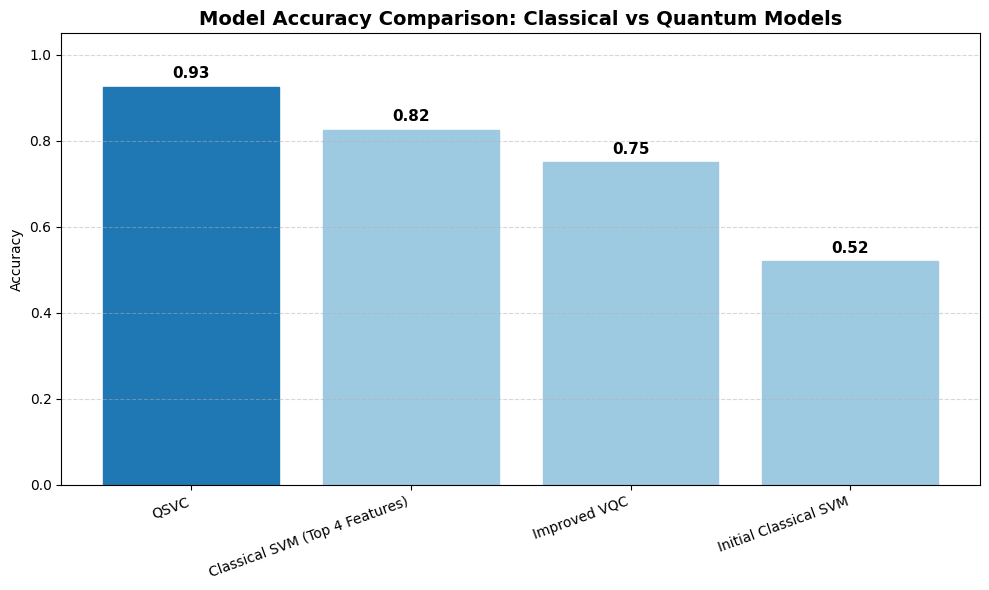

In [84]:
results = pd.DataFrame({
    "Model": [
        "Initial Classical SVM",
        "Classical SVM (Top 4 Features)",
        "QSVC",
        "Improved VQC"
    ],
    "Accuracy": [
        accuracy_score(y_test_init, y_pred_init),
        classical_accuracy,
        qsvc_accuracy,
        vqc_accuracy
    ]
})

results = results.sort_values(by="Accuracy", ascending=False).reset_index(drop=True)
display(results)

plt.figure(figsize=(10, 6))

bars = plt.bar(results["Model"], results["Accuracy"])

# Add labels on top of bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.02,
             f"{height:.2f}",
             ha='center',
             fontsize=11,
             fontweight='bold')

# Highlight QSVC in a different color
bars[0].set_color("#1f77b4")  # QSVC (since sorted)
for i in range(1, len(bars)):
    bars[i].set_color("#9ecae1")

plt.title("Model Accuracy Comparison: Classical vs Quantum Models", fontsize=14, fontweight='bold')
plt.ylabel("Accuracy")
plt.ylim(0, 1.05)
plt.xticks(rotation=20, ha="right")

plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# Observation
### Accuracy Summary
- Initial Classical SVM: **51.98%**
- Classical SVM (Top 4 Features): **82.5%**
- QSVC: **92.5%**
- VQC: **75.0%**

### Key Insight
- Feature selection dramatically improved classical performance.
- QSVC achieved the best overall performance.
- VQC showed moderate performance but required careful tuning.

## 11. Conclusion

In this notebook, we implemented and compared classical and quantum machine learning methods for malware classification using the ClaMP dataset.

### Key Findings
- The initial classical baseline performed poorly (**51.98% accuracy**) due to ineffective feature selection.
- A fair classical SVM baseline improved significantly to **82.5% accuracy** using top correlated features.
- QSVC achieved the best performance with **92.5% accuracy**, demonstrating the effectiveness of quantum kernels.
- VQC achieved **75.0% accuracy**, improving with tuning but remaining less stable than QSVC.

### Final Interpretation
The results indicate that **quantum kernel methods (QSVC)** are highly effective for this classification task, outperforming both classical and variational quantum approaches on the reduced dataset.

### Limitation
- Experiments were limited to **200 samples** due to quantum computational constraints.
- Only **4 features** were used to control qubit count.

### Future Work
- Apply dimensionality reduction techniques such as QPCA
- Test on larger subsets or the full dataset
- Explore deeper ansatz circuits and alternative optimizers